# Phase 4: Exploratory Data Analysis (EDA)

In this phase, we analyze the historical global dataset to uncover underlying patterns, regional differences, and the historical relationship between economic development and carbon emissions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("Loading Data...")
df = pd.read_csv('../data/processed/global_data.csv')
df.head()

Loading Data...


,iso_code,year,gdp_constant_usd,life_expectancy,population,co2,co2_per_capita,energy_per_capita,primary_energy_consumption
0,ABW,1990,1.553994e+09,72.546,62753.0,0.487,7.561,34868.008,2.292
1,ABW,1991,1.677736e+09,72.592,65896.0,0.531,7.981,36834.355,2.500
2,ABW,1992,1.776426e+09,72.717,69005.0,0.539,7.818,39116.551,2.746
3,ABW,1993,1.906242e+09,72.777,73685.0,0.649,9.123,38555.004,2.790
4,ABW,1994,2.062628e+09,72.796,77595.0,0.660,8.976,40968.719,3.062


## 1. Descriptive Statistics
Let's look at the summary statistics of the global dataset.

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6664.0,2.006500e+03,9.811445e+00,1.990000e+03,1.998000e+03,2.006500e+03,2.015000e+03,2.023000e+03
gdp_constant_usd,6664.0,3.070188e+11,1.371372e+12,2.156211e+07,5.201911e+09,2.068186e+10,1.288056e+11,2.195525e+13
life_expectancy,6664.0,6.878946e+01,9.498683e+00,1.215800e+01,6.309100e+01,7.079700e+01,7.580825e+01,8.553268e+01
population,6664.0,3.394955e+07,1.298945e+08,8.798000e+03,1.389712e+06,6.714910e+06,2.163077e+07,1.438070e+09
co2,6664.0,1.477393e+02,6.948992e+02,0.000000e+00,1.444000e+00,8.594000e+00,5.826925e+01,1.190250e+04
co2_per_capita,6664.0,4.785853e+00,7.851236e+00,0.000000e+00,6.050000e-01,2.388000e+00,6.588250e+00,3.646880e+02
energy_per_capita,6664.0,2.450238e+04,3.367989e+04,0.000000e+00,2.777751e+03,1.217274e+04,3.243186e+04,3.175766e+05
primary_energy_consumption,6664.0,6.584151e+02,2.809268e+03,0.000000e+00,6.962250e+00,4.973500e+01,3.083295e+02,4.742756e+04


## 2. Distribution Analysis (Histograms & Boxplots)
Many economic variables like GDP and Population exhibit extreme positive skewness (Pareto distribution). Let's visualize the distributions, including log-transformed versions.

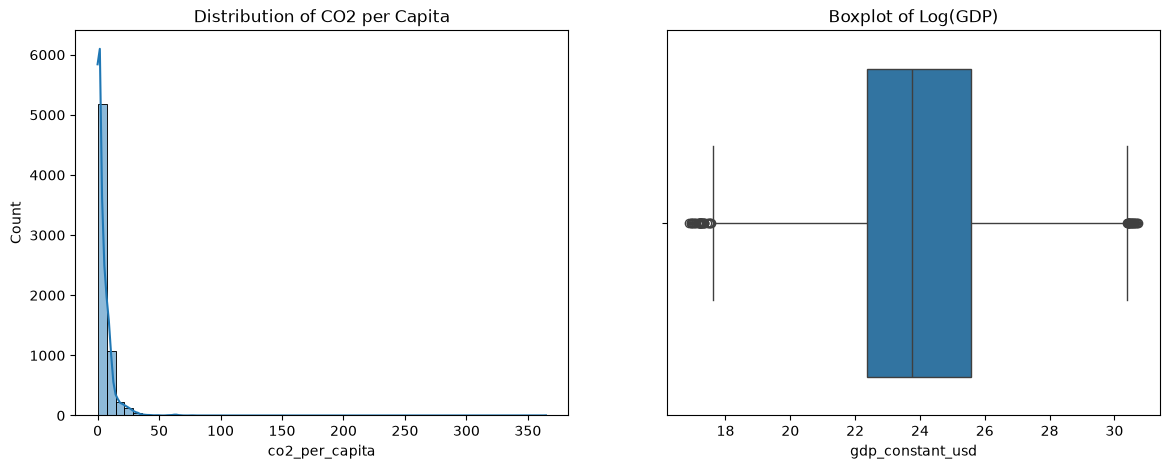

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['co2_per_capita'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of CO2 per Capita')

sns.boxplot(x=np.log1p(df['gdp_constant_usd']), ax=ax[1])
ax[1].set_title('Boxplot of Log(GDP)')
plt.show()

## 3. Correlation Matrices & Heatmaps
A heatmap reveals the linear correlation between major drivers. 
**Hidden Pattern:** Historically, `primary_energy_consumption` and `co2` share an extremely high positive correlation, indicating that energy transitions (away from fossil fuels) have not historically been rapid enough to decouple the two.

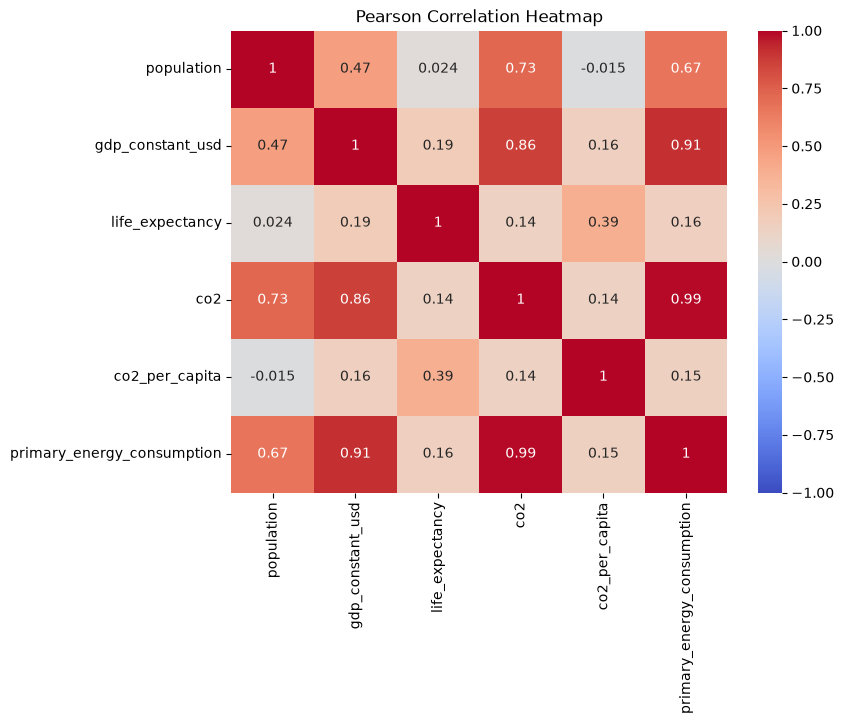

In [4]:
corr_cols = ['population', 'gdp_constant_usd', 'life_expectancy', 'co2', 'co2_per_capita', 'primary_energy_consumption']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap')
plt.show()

## 4. Time-Series Trends & Global Anomalies
Visualizing the aggregate global sum of CO2 emissions and GDP over time.
**Anomalies:** We can observe noticeable dips in Global CO2 emissions around 2008-2009 (Financial Crisis) and 2020 (COVID-19 Pandemic).

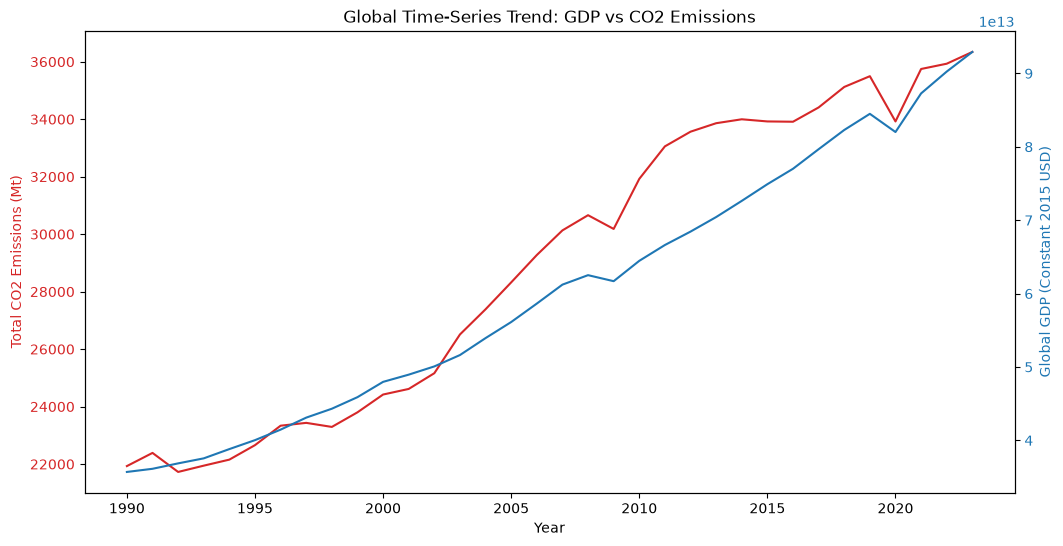

In [5]:
global_trend = df.groupby('year')[['co2', 'gdp_constant_usd']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Year')
ax1.set_ylabel('Total CO2 Emissions (Mt)', color='tab:red')
ax1.plot(global_trend['year'], global_trend['co2'], color='tab:red', label='CO2 Emissions')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Global GDP (Constant 2015 USD)', color='tab:blue')
ax2.plot(global_trend['year'], global_trend['gdp_constant_usd'], color='tab:blue', label='Global GDP')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Global Time-Series Trend: GDP vs CO2 Emissions')
plt.show()

## 5. Geographic Maps & Regional Differences
We use an interactive Plotly choropleth map to visualize regional disparities.
**Regional Differences:** Developed nations (North America, Western Europe, Middle East) historically show significantly higher `co2_per_capita` than Sub-Saharan Africa and South Asia, highlighting global climate inequality.

In [6]:
# Filter for the most recent year in the dataset to map the current state
recent_year = df['year'].max()
df_recent = df[df['year'] == recent_year]

fig = px.choropleth(df_recent, locations="iso_code",
                    color="co2_per_capita",
                    hover_name="iso_code",
                    color_continuous_scale=px.colors.sequential.OrRd,
                    title=f"Global CO2 Emissions per Capita ({recent_year})")

fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="white")
# fig.show() # Uncomment to render interactive plot

## 5. Boxplots — Distribution by Variable
Boxplots reveal the spread, median, and outliers for each key numeric indicator across all countries and years.

In [ ]:
numeric_cols = ['co2', 'co2_per_capita', 'gdp_constant_usd', 'population', 'primary_energy_consumption', 'energy_per_capita']
col_labels   = ['CO₂ (Mt)', 'CO₂/capita (t)', 'GDP (USD)', 'Population', 'Primary Energy (TWh)', 'Energy/capita (kWh)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_cols, col_labels)):
    # Log-transform to handle extreme skew
    data = np.log1p(df[col].dropna())
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2980b9', color='white'),
                    medianprops=dict(color='#f39c12', linewidth=2),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    flierprops=dict(markerfacecolor='#e74c3c', marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(f'{label} (log scale)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('log(1 + value)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots of Key Indicators (log-transformed to handle skew)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Interpretation: Most variables show strong positive skew — a small number of large economies/emitters dominate the global totals.')

## 6. Pair Plot — Feature Relationships
A pair plot reveals pairwise correlations between all numeric features simultaneously.

In [ ]:
# Sample to keep pair plot manageable
sample = df[numeric_cols].dropna().sample(min(2000, len(df)), random_state=42)

pair_fig = sns.pairplot(
    sample,
    vars=numeric_cols,
    diag_kind='kde',
    plot_kws=dict(alpha=0.3, s=10, color='#2980b9'),
    diag_kws=dict(color='#2ecc71', fill=True),
)
pair_fig.figure.suptitle('Pair Plot — All Numeric Features', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Key finding: Strong linear correlations exist between CO₂, Energy, and GDP — confirming the decoupling challenge.')

## 7. Global Time-Series Trends (1990–present)
We aggregate all countries to global totals and visualize the trend for each indicator over time.

In [ ]:
global_ts = df.groupby('year')[['co2', 'gdp_constant_usd', 'population', 'primary_energy_consumption']].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_configs = [
    ('co2',                      'Global CO₂ Emissions (Mt)',         '#e74c3c'),
    ('gdp_constant_usd',         'Global GDP (constant USD)',          '#2ecc71'),
    ('population',               'Global Population',                  '#3498db'),
    ('primary_energy_consumption','Global Primary Energy (TWh)',       '#f39c12'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_configs):
    ax.plot(global_ts.index, global_ts[col], color=color, linewidth=2.5)
    ax.fill_between(global_ts.index, global_ts[col], alpha=0.15, color=color)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)
    # Mark COVID dip
    if 2020 in global_ts.index:
        ax.axvline(2020, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.text(2020.2, ax.get_ylim()[0]*1.02, 'COVID', fontsize=8, color='gray')

plt.suptitle('Global Time-Series Trends (1990–present)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: COVID-19 caused a visible dip in CO₂ emissions in 2020, but emissions rebounded sharply in 2021.')